In [1]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
column_names = [
    'id', 'diagnosis',
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
    'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean',
    'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
    'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
    'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
    'smoothness_worst', 'compactness_worst', 'concavity_worst',
    'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

df = pd.read_csv("wdbc.data", header=None, names=column_names)

df.drop('id', axis=1, inplace=True)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


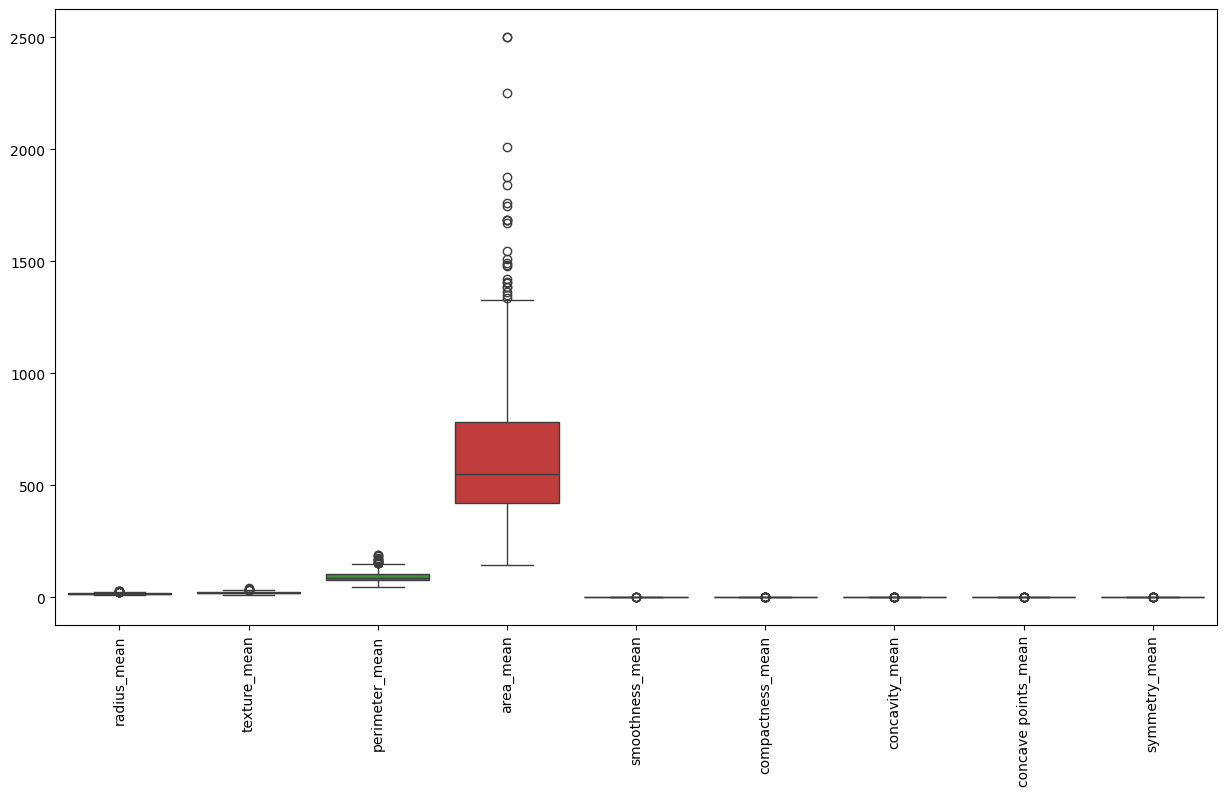

In [3]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df.iloc[:,:10])
plt.xticks(rotation=90)
plt.show()

In [4]:
df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [5]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [6]:
imputer = SimpleImputer(strategy='mean')
df.iloc[:,1:] = imputer.fit_transform(df.iloc[:,1:])

In [7]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Bagging DT 

In [17]:
n_estimators = 100
n_samples = X_train.shape[0]

models = []


for i in range(n_estimators):
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    
    X_sample = X_train[indices]
    y_sample = y_train.iloc[indices]
    
    model = DecisionTreeClassifier()
    model.fit(X_sample, y_sample)
    
    models.append(model)

predictions = []

for model in models:
    pred = model.predict(X_test)
    predictions.append(pred)

predictions = np.array(predictions)

predictions = predictions.T

final_predictions = []

for sample_preds in predictions:
    counts = np.bincount(sample_preds)
    final_predictions.append(np.argmax(counts))

final_predictions = np.array(final_predictions)

print("Bagging Accuracy:",
      accuracy_score(y_test, final_predictions))

Bagging Accuracy: 0.956140350877193


### AdBoost Mann

In [21]:
y_train_boost = y_train.copy()
y_test_boost = y_test.copy()

y_train_boost = y_train_boost.replace(0, -1)
y_test_boost = y_test_boost.replace(0, -1)

y_train_boost = y_train_boost.values
y_test_boost = y_test_boost.values

n_samples = X_train.shape[0]
n_estimators = 100

# Initialize equal weights
weights = np.ones(n_samples) / n_samples

models = []
alphas = []

In [23]:
for _ in range(n_estimators):
    
    # Weak learner (decision stump)
    stump = DecisionTreeClassifier(max_depth=1)
    
    stump.fit(X_train, y_train_boost, sample_weight=weights)
    
    predictions = stump.predict(X_train)
    
    # Compute weighted error
    misclassified = predictions != y_train_boost
    error = np.sum(weights * misclassified)
    
    # Avoid division by zero
    error = max(error, 1e-10)
    
    # Compute model weight (alpha)
    alpha = 0.5 * np.log((1 - error) / error)
    
    # Update sample weights
    weights = weights * np.exp(-alpha * y_train_boost * predictions)
    
    # Normalize weights
    weights = weights / np.sum(weights)
    
    models.append(stump)
    alphas.append(alpha)

In [22]:
adaboost = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

adaboost.fit(X_train, y_train)

y_pred_boost = adaboost.predict(X_test)

print("Boosting Accuracy:", accuracy_score(y_test, y_pred_boost))

Boosting Accuracy: 0.9736842105263158


In [13]:
estimators = [
    ('dt', DecisionTreeClassifier()),
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42))
]

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=DecisionTreeClassifier()
)

stacking.fit(X_train, y_train)

y_pred_stack = stacking.predict(X_test)

print("Stacking Accuracy:", accuracy_score(y_test, y_pred_stack))

Stacking Accuracy: 0.9736842105263158


In [14]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9649122807017544


In [15]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Confusion Matrix:
 [[70  1]
 [ 3 40]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

